# GloVe: 全局向量词嵌入 实现详解

## 核心思想

GloVe（Global Vectors for Word Representation）的核心思想是：**词向量应该编码词与词之间共现统计的信息**。

与 Word2Vec 不同，GloVe 不依赖局部上下文窗口的预测任务，而是直接从**全局共现矩阵**中学习词向量。

### GloVe 的目标函数

GloVe 的损失函数基于共现矩阵中的非零元素：

$$J = \sum_{i,j} f(X_{ij}) \cdot (w_i^T \tilde{w}_j + b_i + \tilde{b}_j - \log X_{ij})^2$$

其中：
- $X_{ij}$：词 $i$ 和词 $j$ 的共现次数
- $w_i, \tilde{w}_j$：词 $i$ 和词 $j$ 的嵌入向量（中心词和上下文词分别有独立的向量）
- $b_i, \tilde{b}_j$：偏置项
- $f(X_{ij})$：权重函数，控制高频共现对的影响

### 权重函数 f(x)

$$f(x) = \begin{cases} (x/x_{max})^{0.75} & \text{if } x < x_{max} \\ 1 & \text{otherwise} \end{cases}$$

作用：限制极高频共现对的影响，避免常见词对（如 'the'-'a'）主导训练。

## 1. 构建共现矩阵

共现矩阵 $X$ 是一个 $|V| \times |V|$ 的矩阵，其中 $X_{ij}$ 表示词 $i$ 和词 $j$ 在给定窗口大小内的共现次数。

例如，窗口大小为 2 时：
```
句子: "the quick brown fox"
共现对: (the, quick), (the, brown), (quick, the), (quick, brown), (quick, fox), ...
```

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from collections import Counter, defaultdict
import numpy as np

In [2]:
# 语料
corpus = [
    "the quick brown fox jumps over the lazy dog",
    "the dog sleeps under the tree",
    "a quick brown fox runs fast"
]
sentences = [s.lower().split() for s in corpus]

# 构建词汇表
vocab = list(set([w for sent in sentences for w in sent]))
vocab_size = len(vocab)
word_to_idx = {w: i for i, w in enumerate(vocab)}
idx_to_word = {i: w for w, i in word_to_idx.items()}

print(f"词汇表大小: {vocab_size}")
print(f"词汇表: {vocab}")

词汇表大小: 14
词汇表: ['runs', 'a', 'fox', 'fast', 'jumps', 'the', 'sleeps', 'dog', 'brown', 'quick', 'lazy', 'under', 'over', 'tree']


In [3]:
# 统计共现次数（窗口大小为2）
window = 2
cooccur = defaultdict(int)

for sent in sentences:
    for i, w in enumerate(sent):
        # 取窗口范围内的所有词（排除自身）
        for j in range(max(0, i - window), min(len(sent), i + window + 1)):
            if i != j:
                cooccur[(word_to_idx[w], word_to_idx[sent[j]])] += 1

# 展示共现矩阵
print("共现矩阵（非零元素）:")
for (i, j), count in sorted(cooccur.items(), key=lambda x: -x[1]):
    print(f"  ({idx_to_word[i]}, {idx_to_word[j]}): {count}")

共现矩阵（非零元素）:
  (quick, brown): 2
  (quick, fox): 2
  (brown, quick): 2
  (brown, fox): 2
  (fox, quick): 2
  (fox, brown): 2
  (the, dog): 2
  (dog, the): 2
  (the, sleeps): 2
  (sleeps, the): 2
  (the, quick): 1
  (the, brown): 1
  (quick, the): 1
  (brown, the): 1
  (brown, jumps): 1
  (fox, jumps): 1
  (fox, over): 1
  (jumps, brown): 1
  (jumps, fox): 1
  (jumps, over): 1
  (jumps, the): 1
  (over, fox): 1
  (over, jumps): 1
  (over, the): 1
  (over, lazy): 1
  (the, jumps): 1
  (the, over): 1
  (the, lazy): 1
  (lazy, over): 1
  (lazy, the): 1
  (lazy, dog): 1
  (dog, lazy): 1
  (dog, sleeps): 1
  (dog, under): 1
  (sleeps, dog): 1
  (sleeps, under): 1
  (under, dog): 1
  (under, sleeps): 1
  (under, the): 1
  (under, tree): 1
  (the, under): 1
  (the, tree): 1
  (tree, under): 1
  (tree, the): 1
  (a, quick): 1
  (a, brown): 1
  (quick, a): 1
  (brown, a): 1
  (brown, runs): 1
  (fox, runs): 1
  (fox, fast): 1
  (runs, brown): 1
  (runs, fox): 1
  (runs, fast): 1
  (fast, fox): 1


In [4]:
# 为了节省内存，只存储非零对
pairs = list(cooccur.keys())
X = torch.tensor([cooccur[p] for p in pairs], dtype=torch.float32)

print(f"非零共现对数量: {len(pairs)}")
print(f"共现次数范围: [{X.min().item():.0f}, {X.max().item():.0f}]")

非零共现对数量: 56
共现次数范围: [1, 2]


## 2. GloVe 模型定义

### 模型结构

GloVe 模型包含：
- `w_embed`：中心词嵌入向量 $w_i$
- `c_embed`：上下文词嵌入向量 $\tilde{w}_j$
- `w_bias`：中心词偏置 $b_i$
- `c_bias`：上下文词偏置 $\tilde{b}_j$

### 前向传播

对于共现对 $(i, j)$，损失计算为：

$$\text{loss} = f(X_{ij}) \cdot (w_i^T \tilde{w}_j + b_i + \tilde{b}_j - \log X_{ij})^2$$

即：预测值（向量点积 + 偏置）与真实值（共现次数的对数）之间的加权平方误差。

In [5]:
class GloVeModel(nn.Module):
    """
    GloVe 词向量模型
    
    目标：让 w_i^T * w_j + b_i + b_j ≈ log(X_ij)
    即：两个词向量的点积加上偏置应接近共现次数的对数
    """
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        # 两套独立的嵌入向量
        self.w_embed = nn.Embedding(vocab_size, embed_dim)   # 中心词向量
        self.c_embed = nn.Embedding(vocab_size, embed_dim)   # 上下文词向量
        # 偏置项（每个词一个标量偏置）
        self.w_bias = nn.Embedding(vocab_size, 1)
        self.c_bias = nn.Embedding(vocab_size, 1)
        
        # Xavier 初始化嵌入向量
        nn.init.xavier_uniform_(self.w_embed.weight)
        nn.init.xavier_uniform_(self.c_embed.weight)
        # 偏置初始化为0
        self.w_bias.weight.data.zero_()
        self.c_bias.weight.data.zero_()
        
    def forward(self, i, j, X_ij):
        """
        i: 中心词索引
        j: 上下文词索引
        X_ij: 共现次数
        """
        w_i = self.w_embed(i)          # (B, D)
        c_j = self.c_embed(j)          # (B, D)
        b_i = self.w_bias(i).squeeze() # (B,)
        b_j = self.c_bias(j).squeeze() # (B,)
        
        # 核心损失：(w_i · c_j + b_i + b_j - log(X_ij))^2
        loss = (torch.sum(w_i * c_j, dim=1) + b_i + b_j - torch.log(X_ij)) ** 2
        
        # 权重函数 f(X_ij) = min(1.0, (X/100)^0.75)
        weight = torch.where(X_ij < 100, (X_ij / 100) ** 0.75, torch.ones_like(X_ij))
        
        return (weight * loss).mean()

C:\Users\86187\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26435 (\N{CJK UNIFIED IDEOGRAPH-6743}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\86187\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\86187\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20989 (\N{CJK UNIFIED IDEOGRAPH-51FD}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\86187\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\86187\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 208

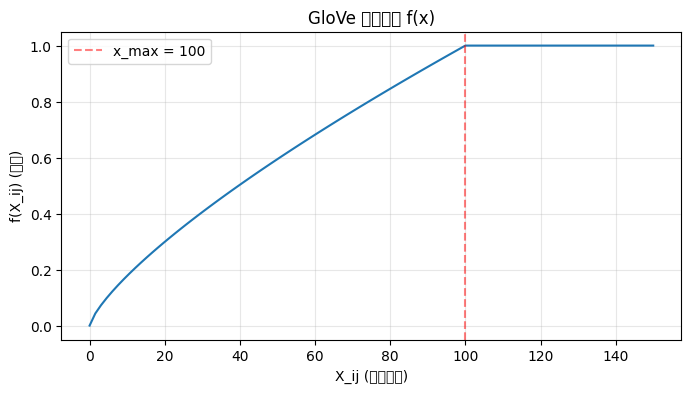

解释：
- 低频共现（x<100）：权重随频率增加而增加，但增长速度递减（0.75次方）
- 高频共现（x>=100）：权重固定为1，避免极高频词对主导训练


In [6]:
# 权重函数可视化
x = torch.linspace(0, 150, 100)
weight = torch.where(x < 100, (x / 100) ** 0.75, torch.ones_like(x))

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(x.numpy(), weight.numpy())
plt.xlabel('X_ij (共现次数)')
plt.ylabel('f(X_ij) (权重)')
plt.title('GloVe 权重函数 f(x)')
plt.axvline(x=100, color='r', linestyle='--', alpha=0.5, label='x_max = 100')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("解释：")
print("- 低频共现（x<100）：权重随频率增加而增加，但增长速度递减（0.75次方）")
print("- 高频共现（x>=100）：权重固定为1，避免极高频词对主导训练")

## 3. 训练 GloVe 模型

训练过程：
1. 随机打乱所有共现对
2. 对每个共现对，计算加权平方误差损失
3. 反向传播，更新词向量和偏置

GloVe 的训练效率很高，因为每个样本都是独立的共现对，可以高效地进行随机梯度下降。

In [7]:
# 超参数
embed_dim = 50
lr = 0.1
epochs = 200

model = GloVeModel(vocab_size, embed_dim)
optimizer = optim.Adam(model.parameters(), lr=lr)

print(f"嵌入维度: {embed_dim}")
print(f"参数总量: {sum(p.numel() for p in model.parameters()):,}")

嵌入维度: 50
参数总量: 1,428


In [8]:
losses = []

for epoch in range(epochs):
    total_loss = 0
    # 随机打乱共现对
    indices = np.random.permutation(len(pairs))
    
    for idx in indices:
        i, j = pairs[idx]
        x_ij = X[idx].view(1)
        i_t = torch.tensor([i])
        j_t = torch.tensor([j])
        
        optimizer.zero_grad()
        loss = model(i_t, j_t, x_ij)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(pairs)
    losses.append(avg_loss)
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:3d}, Loss: {avg_loss:.4f}")

Epoch  50, Loss: 0.0035
Epoch 100, Loss: 0.0000
Epoch 150, Loss: 0.2114
Epoch 200, Loss: 2.6388


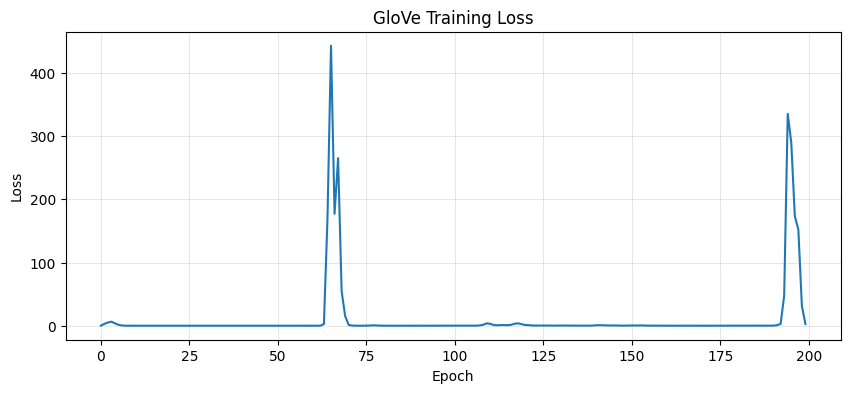

In [9]:
# 绘制损失曲线
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GloVe Training Loss')
plt.grid(True, alpha=0.3)
plt.show()

## 4. 获取最终词向量

GloVe 学习了两套向量（中心词和上下文词），最终词向量通常取两者的**平均值**：

$$v_w = \frac{w_i + \tilde{w}_i}{2}$$

也有研究表明只使用其中一套向量也可以达到不错的效果。

In [ ]:
# 最终词向量取两套向量的平均
final_embeds = (model.w_embed.weight.data + model.c_embed.weight.data) / 2

def get_vector(word):
    idx = word_to_idx[word]
    return final_embeds[idx].numpy()

print("GloVe 词向量示例:")
print(f"'fox' 前5维: {get_vector('fox')[:5]}")
print(f"'dog' 前5维: {get_vector('dog')[:5]}")

In [ ]:
# 余弦相似度
def cosine_sim(vec1, vec2):
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

fox_vec = get_vector('fox')
dog_vec = get_vector('dog')
tree_vec = get_vector('tree')
quick_vec = get_vector('quick')

print("词向量相似度:")
print(f"  fox <-> dog:   {cosine_sim(fox_vec, dog_vec):.4f}")
print(f"  fox <-> tree:  {cosine_sim(fox_vec, tree_vec):.4f}")
print(f"  fox <-> quick: {cosine_sim(fox_vec, quick_vec):.4f}")
print(f"  dog <-> tree:  {cosine_sim(dog_vec, tree_vec):.4f}")

## 5. GloVe vs Word2Vec

| 特性 | Word2Vec | GloVe |
|------|----------|-------|
| **训练方式** | 基于局部上下文窗口的预测任务 | 基于全局共现矩阵的分解 |
| **信息利用** | 只利用局部上下文 | 利用全局共现统计 |
| **训练效率** | 需要大量迭代 | 收敛较快 |
| **数学基础** | 预测模型 | 矩阵分解（类似SVD） |
| **最终向量** | 通常取 center_embed | 通常取 center + context 的平均 |

两者在实践中效果相近，GloVe 的优势在于训练更快且更容易理解其数学原理。

## 总结

| 概念 | 说明 |
|------|------|
| 共现矩阵 | 记录词与词在窗口内的共现次数 |
| 权重函数 f(x) | 限制高频共现对的影响，使训练更稳定 |
| 目标函数 | 让 w_i · w_j + b_i + b_j ≈ log(X_ij) |
| 两套嵌入 | 中心词和上下文词分别有独立的向量和偏置 |
| 最终向量 | 取两套向量的平均值 |